In [1]:
import re
import os
import argparse
import gzip
from itertools import product
from Bio import bgzf, SeqIO
from loguru import logger
from typing import List
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

import json

from datasets import Dataset, load_from_disk
from transformers import PreTrainedTokenizerFast
from tokenizers import processors

import evaluate

/Users/achamorro/miniconda3/envs/translast/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from transformers import Trainer as Trainer, AlbertForSequenceClassification, AlbertConfig, TrainingArguments
from transformers import PreTrainedTokenizerFast, default_data_collator, DataCollatorWithPadding

In [3]:
def try_mkdir(dir_name):
    # Save the tokenizer
    try:
        os.makedirs(dir_name)
    except FileExistsError:
            # directory already exists
            pass

class GenomeDataset(Dataset):

    def __init__(self, file_path, file_format, transform=None, target_transform=None):
        self.file_path = file_path
        self.file_format = file_format
        self.transform = transform
        self.target_transform = target_transform
        self.sequences, self.complement, self.ids = self._load_sequences()
        self._index = 0  # Initialize the index for iteration

    def _load_sequences(self):
        sequences = []
        complement = []
        ids = []
        with self._file_handle() as handle:
            for record in SeqIO.parse(handle, self.file_format):
                sequences.append(self._standardization(str(record.seq)))
                complement.append(self._standardization(str(record.seq.reverse_complement())))
                ids.append(str(record.id))
                pass
        return sequences, complement, ids
    
    def _standardization(self, sequence):
        return re.sub(r'[^ACTGN]', '', sequence.upper())
    
    def _file_handle(self):
        if self.file_path.endswith('.gz'):
            return gzip.open(self.file_path, 'rt')
        elif self.file_path.endswith('.bgz'):
            return bgzf.open(self.file_path, 'rt')
        else :
            return open(self.file_path, 'rt')
    
    def __len__(self):
        return len(self.sequences)
    
    def __iter__(self):
        self._index = 0  # Reset the index for a new iteration
        return self
    
    def __next__(self):
        if self._index < len(self.sequences):
            seq = self.sequences[self._index]
            rev = self.complement[self._index]
            i = self.ids[self._index]
            self._index += 1
            return seq, rev, i
        else:
            raise StopIteration
    
    def __getitem__(self, index):
        if isinstance(index, slice):
            return self.sequences[index], self.complement[index]
        elif isinstance(index, int):
            if index < 0:
                index += len(self.sequences)
            if index >= len(self.sequences) or index < 0:
                raise IndexError("The index is out of range.")
            seq = self.sequences[index]
            rev = self.complement[index]
            i = self.ids[index]
            if self.transform:
                seq, rev, i = self.transform(seq, rev, i)
            if self.target_transform:
                index = self.target_transform(index)
            return seq, rev, i, index
        else:
            raise TypeError("Invalid argument type.")
        
# Seq compression
def seq_to_encoded(seq, encoding=None):
    # Define the nucleotides
    nucleotides = ['A', 'C', 'G', 'T']
    # TODO: Handle the padding if the seq is not div by 2
    if encoding in ("pairs", "2-mers", 2):
        # Generate all possible 2-mers
        pairs = [''.join(p) for p in product(nucleotides, repeat=2)]
        
        # Create a dictionary with 2-mers as keys and Unicode characters as values
        pairs_to_unicode = {pair: chr(65 + i) for i, pair in enumerate(pairs)}
        return ''.join(pairs_to_unicode[seq[i:i+2]] for i in range(0, len(seq)-1, 2))
    
    # TODO: Handle the padding if the seq is not div by 3
    if encoding in ("codons", "3-mers", 3):
        # Generate all possible 3-mers (codons)
        codons = [''.join(p) for p in product(nucleotides, repeat=3)]
        # Create a dictionary with 3-mers as keys and Unicode characters as values
        codons_to_unicode = {codon: chr(65 + i) for i, codon in enumerate(codons)}
        return ''.join(codons_to_unicode[seq[i:i+3]] for i in range(0, len(seq)-2, 3))
    # Do nothing
    return seq

def create_lambda_with_globals(s):
    return eval(s, globals())

def _kmer_split(k: int, sequence: str, encoding: str=None) -> List[str]:
    return " ".join([seq_to_encoded(sequence[j: j + k], encoding=encoding) for j in range(len(sequence) - k + 1)])

def get_label_list(raw_dataset, split="train") -> list[str]:
    """Get the list of labels from a multi-label dataset"""

    if isinstance(raw_dataset[split]["label"][0], list):
        label_list = [label for sample in raw_dataset[split]["label"] for label in sample]
        label_list = list(set(label_list))
    else:
        label_list = raw_dataset[split].unique("label")
    # we will treat the label list as a list of string instead of int, consistent with model.config.label2id
    label_list = [str(label) for label in label_list]
    return label_list

def dataset_loader(builder='gencode.v47.transcripts.fa.gz', pair=None, file_format='fasta', k=18, batch_size=1000, test_split=0.1, val_split=None, class_threshold = None, num_proc=4):
    logger.info(f"Loading sequence {builder}.")
    raw_datasets = GenomeDataset(builder, file_format)
    if pair is not None:
        pair_datasets = GenomeDataset(pair, file_format)
        def generator_from_iterator():
            for (r1, rv1, i1), (r2, rv2, i2) in zip(raw_datasets, pair_datasets):
                yield {'read_1': r1, 
                       'kmers_1': _kmer_split(k, r1),
                       'read_2': r2, 
                       'kmers_2': _kmer_split(k, r2), 
                       'label': i1.split('|')[1].split('-')[0]}
    else:
        def generator_from_iterator():
            for seq, rev, id in raw_datasets:
                yield {'sequence': seq, 'kmers': _kmer_split(k, seq), 'label': id.split('|')[1].split('-')[0]}
        pass
    

    logger.info("Create datasets from GenomeIterator")
    dataset = Dataset.from_generator(generator_from_iterator)
    dataset = dataset.class_encode_column('label')
    
    if class_threshold is not None:
        # Count the occurrences of each label
        label_counts = Counter(dataset['label'])
        # Filter the dataset based on the threshold
        dataset = dataset.filter(lambda example: label_counts[example['label']] >= class_threshold, num_proc=num_proc)
        pass

    logger.info("Creating train-test split")
    dataset = dataset.train_test_split(test_size=(test_split + val_split), stratify_by_column = 'label')

    if val_split is not None:
        logger.info("Creating train-eval split")
        test_eval_split = dataset['test'].train_test_split(test_size=test_split/(test_split + val_split), stratify_by_column = 'label')
        dataset['test'] = test_eval_split['train']
        dataset['eval'] = test_eval_split['test']
        pass

    return dataset

In [4]:
# def ascii_histogram(counted) -> None:
#     """A horizontal frequency-table/histogram plot."""
#     for k in sorted(counted):
#         print('{0} {1}'.format(k, '+' * counted[k]))

# k = 18
# raw_datasets = GenomeDataset('../data/raw/RepeatMasker/GCF_000001405.40_GRCh38.p14_rm.LINE1.transcript/art/GRCh38.p14.rmtranscriptome.single.5x.fq.gz', file_format='fastq')
# def generator_from_iterator(raw_datasets):
#    for seq, rev, id in raw_datasets:
#        yield {'sequence': seq, 'kmers': _kmer_split(k, seq), 'label': id.split('|')[1].split('-')[0]}

# logger.info("Create datasets from GenomeIterator")
# dataset = Dataset.from_generator(generator_from_iterator, gen_kwargs={"raw_datasets": raw_datasets})

In [5]:
# Box plot
# filter_counts = list(filter(lambda c: c < 0.2e5, label_counts.values()))
# plt.boxplot(filter_counts, vert=False, patch_artist=True, boxprops=dict(facecolor='cyan'))
# plt.title("Box Plot")
# plt.xlabel("Value")
# plt.show()

In [6]:
builder = '../data/raw/RepeatMasker/GCF_000001405.40_GRCh38.p14_rm.LINE1.transcript/art/GRCh38.p14.rmtranscriptome.pair.l1hs_l1pa2_negative.2x_1.fq'
pair = '../data/raw/RepeatMasker/GCF_000001405.40_GRCh38.p14_rm.LINE1.transcript/art/GRCh38.p14.rmtranscriptome.pair.l1hs_l1pa2_negative.2x_2.fq'

transcripts_dataset = dataset_loader(builder = builder, pair=pair, file_format='fastq', test_split=0.20, val_split=0.20)

2025-05-05 11:51:17.089 | INFO     | __main__:dataset_loader:120 - Loading sequence ../data/raw/RepeatMasker/GCF_000001405.40_GRCh38.p14_rm.LINE1.transcript/art/GRCh38.p14.rmtranscriptome.pair.l1hs_l1pa2_negative.2x_1.fq.
2025-05-05 11:51:17.323 | INFO     | __main__:dataset_loader:138 - Create datasets from GenomeIterator
Generating train split: 25459 examples [00:01, 20617.00 examples/s]
Casting to class labels: 100%|██████████| 25459/25459 [00:00<00:00, 605674.21 examples/s]
2025-05-05 11:51:18.737 | INFO     | __main__:dataset_loader:149 - Creating train-test split
2025-05-05 11:51:18.747 | INFO     | __main__:dataset_loader:153 - Creating train-eval split


1st Quartile (Q1): 3574.0
2nd Quartile (Q2)/Median: 5906.0
3rd Quartile (Q3): 7016.5

NEGATIVE vs Rest:
NEGATIVE: 5906
Rest: 9369


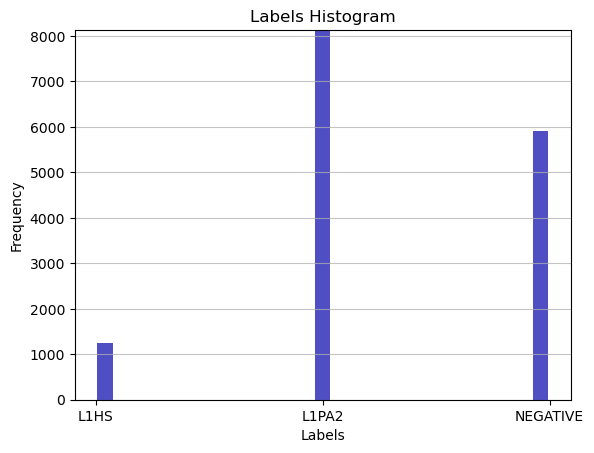

In [7]:
# Extract labels
int2str = transcripts_dataset['train'].features['label'].int2str
labels = np.array([int2str(i) for i in transcripts_dataset['train']['label']])
for split in ["eval", "test"]:
    int2str = transcripts_dataset[split].features['label'].int2str
    val_or_test_labels = [int2str(i) for i in transcripts_dataset[split]['label']]
    diff = set(val_or_test_labels).difference(set(labels))
    if len(diff) > 0:
        # add the labels that appear in val/test but not in train, throw a warning
        logger.warning(
            f"Labels {diff} in {split} set but not in training set, adding them to the label list"
        )
        labels += list(diff)

# Count all labels
label_counts = Counter(labels)
quartiles = np.quantile(list(label_counts.values()), [0.25, 0.5, 0.75])
print(f"1st Quartile (Q1): {quartiles[0]}")
print(f"2nd Quartile (Q2)/Median: {quartiles[1]}")
print(f"3rd Quartile (Q3): {quartiles[2]}")

# Count NEGATIVE vs the rest
negative_count = label_counts['NEGATIVE']
rest_count = sum(count for label, count in label_counts.items() if label != 'NEGATIVE')
   
# An "interface" to matplotlib.axes.Axes.hist() method
n, bins, patches = plt.hist(x=labels, bins='auto', color='#0504aa', alpha=0.7, rwidth=0.85)
plt.grid(axis='y', alpha=0.75)
plt.xlabel('Labels')
plt.ylabel('Frequency')
plt.title('Labels Histogram')
maxfreq = n.max()
    
# Set a clean upper y-axis limit.
plt.ylim(ymax=np.ceil(maxfreq / 10) * 10 if maxfreq % 10 else maxfreq + 10)
    
print("\nNEGATIVE vs Rest:")
print(f"NEGATIVE: {negative_count}")
print(f"Rest: {rest_count}")

In [8]:
labels

array(['L1HS', 'L1PA2', 'L1HS', ..., 'L1PA2', 'L1PA2', 'NEGATIVE'],
      shape=(15275,), dtype='<U8')

In [9]:
label_list = transcripts_dataset['train'].features['label'].names
for split in ["eval", "test"]:
    val_or_test_labels = transcripts_dataset[split].features['label'].names
    diff = set(val_or_test_labels).difference(set(label_list))
    if len(diff) > 0:
        # add the labels that appear in val/test but not in train, throw a warning
        logger.warning(
            f"Labels {diff} in {split} set but not in training set, adding them to the label list"
        )
        label_list += list(diff)
# if label is -1, we throw a warning and remove it from the label list
for label in label_list:
    if transcripts_dataset['train'].features['label'].str2int(label) == -1:
        logger.warning("Label -1 found in label list, removing it.")
        label_list.remove(label)
    
label_list.sort()

In [11]:
logger.info("Loading pretrained tokenizer")
pretrained_model_path = 'transcripts_sentencepiece/unigram/kmerpiece/gencode.v47.transcripts.k18.32k.skipn.nocompress/huggingface/fast'
tokenizer = PreTrainedTokenizerFast.from_pretrained(pretrained_model_name_or_path=pretrained_model_path, local_files_only=True)
tokenizer.post_processor = processors.TemplateProcessing(
    single="[CLS]:0 $A:0 [SEP]:0",
    pair="[CLS]:0 $A:0 [SEP]:0 $B:1 [SEP]:1",
    special_tokens=[
        ("[CLS]", tokenizer.convert_tokens_to_ids("[CLS]")),
        ("[SEP]", tokenizer.convert_tokens_to_ids("[SEP]")),
    ],
)
tokenizer.model_max_length = 1024

2025-05-05 11:51:42.159 | INFO     | __main__:<module>:1 - Loading pretrained tokenizer


In [12]:
if pair is not None:
    print("is Pair")
    remove_columns=['read_1', 'read_2', 'kmers_1', 'kmers_2']
    def tokenize_function(examples):
        result = tokenizer(examples["kmers_1"], examples["kmers_2"], padding='max_length', pad_to_multiple_of=8, truncation=True, verbose=False)
        return result
else:
    remove_columns=['sequence', 'kmers']
    def tokenize_function(examples):
        result = tokenizer(examples["kmers"], padding='max_length', pad_to_multiple_of=8, truncation=True, verbose=False)
        return result
    pass

tokenized_datasets = transcripts_dataset.map(
    tokenize_function, batched=True, remove_columns=remove_columns, load_from_cache_file=False, num_proc=4,
    desc="Running tokenizer on dataset"
)

is Pair


Running tokenizer on dataset (num_proc=4): 100%|██████████| 5092/5092 [00:02<00:00, 1800.46 examples/s]


In [13]:
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 15275
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5092
    })
    eval: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5092
    })
})

Mean length: 1017.4993780687398
Median length: 1014.0
Max length: 1039
Min length: 1007


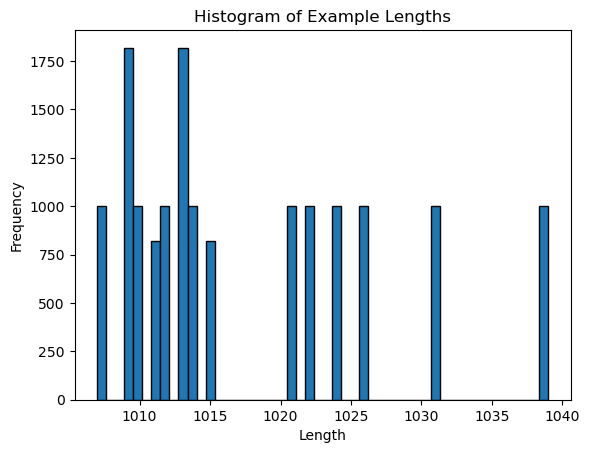

In [11]:
# Calculate the length of each example
lengths = [example['lengths'] for example in tokenized_datasets['train']]

# Print statistics
print(f"Mean length: {np.mean(lengths)}")
print(f"Median length: {np.median(lengths)}")
print(f"Max length: {np.max(lengths)}")
print(f"Min length: {np.min(lengths)}")

# Plot histogram
plt.hist(lengths, bins=50, edgecolor='black')
plt.title('Histogram of Example Lengths')
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.show()


Mean length: 1024.0
Median length: 1024.0
Max length: 1024
Min length: 1024


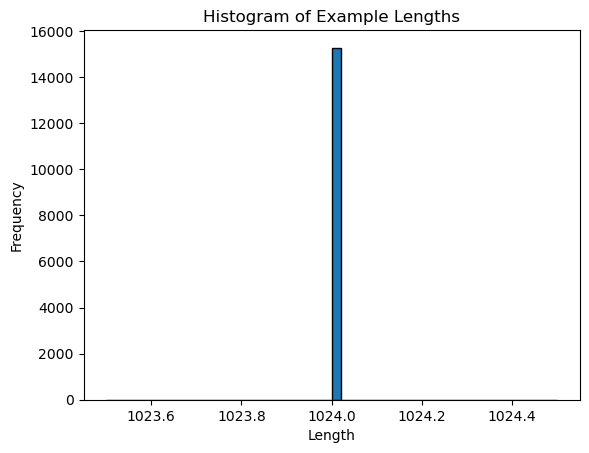

In [14]:
# Calculate the length of each example
lengths = [len(example['input_ids']) for example in tokenized_datasets['train']]

# Print statistics
print(f"Mean length: {np.mean(lengths)}")
print(f"Median length: {np.median(lengths)}")
print(f"Max length: {np.max(lengths)}")
print(f"Min length: {np.min(lengths)}")

# Plot histogram
plt.hist(lengths, bins=50, edgecolor='black')
plt.title('Histogram of Example Lengths')
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.show()

In [15]:
PROCESSED_DATA_DIR = '../data/processed'
preprocessing_name='gencode.v47.transcripts.k18.32k.skipn.nocompress'
try_mkdir(os.path.join(PROCESSED_DATA_DIR, preprocessing_name, 'classification'))
tokenized_datasets.save_to_disk(os.path.join(PROCESSED_DATA_DIR, preprocessing_name, 'classification'))

Saving the dataset (1/1 shards): 100%|██████████| 5092/5092 [00:00<00:00, 220070.44 examples/s]


In [16]:
logger.info("Training ALBERT model...")

# Extract the ClassLabel feature
class_labels = tokenized_datasets['train'].features['label']
# Create label2id and id2label mappings
label2id = {label: class_labels.str2int(label) for label in class_labels.names}
id2label = {class_labels.str2int(label): label for label in class_labels.names}
 
model = AlbertForSequenceClassification.from_pretrained(pretrained_model_path, num_labels=len(class_labels.names), id2label=id2label, label2id=label2id)

2025-05-01 20:35:59.468 | INFO     | __main__:<module>:1 - Training ALBERT model...
Some weights of AlbertForSequenceClassification were not initialized from the model checkpoint at ../models/albert.gencode.v47.transcripts.k18.32k/final and are newly initialized: ['albert.pooler.bias', 'albert.pooler.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [17]:
model_num_parameters = model.num_parameters() / 1_000_000
logger.info(f"'Custom Genomics AlBERT number of parameters: {round(model_num_parameters)}M'")
logger.info("Original ALBERT number of parameters: 11M")
logger.info("Original BERT number of parameters: 110M")

2025-05-01 20:37:44.406 | INFO     | __main__:<module>:2 - 'Custom Genomics AlBERT number of parameters: 12M'
2025-05-01 20:37:44.408 | INFO     | __main__:<module>:3 - Original ALBERT number of parameters: 11M
2025-05-01 20:37:44.409 | INFO     | __main__:<module>:4 - Original BERT number of parameters: 110M


In [35]:
trainer_config_path='../config/trainer_config_base_repeatmasker.json'
trainer_args = TrainingArguments(**json.load(open(trainer_config_path, 'r')))
model_name = 'albert.repeatmasker.k18.32k'
trainer_args.output_dir = os.path.join('../models', model_name)

In [33]:
clf_metrics = evaluate.combine(["accuracy", "f1", "precision", "recall"])
logger.info("Using accuracy, f1, precision and recall as classification score, you can use --metric_name to overwrite.")

2025-05-01 23:16:31.543 | INFO     | __main__:<module>:2 - Using accuracy, f1, precision and recall as classification score, you can use --metric_name to overwrite.


In [34]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return clf_metrics.compute(predictions=predictions, references=labels)

In [38]:
data_collator = DataCollatorWithPadding(tokenizer)

trainer = Trainer(
    model=model,
    args=trainer_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["eval"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [39]:
train_result = trainer.train()
logger.success("Modeling training complete.")

Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 